# Comparison of Downwelling Longwave radiation between JRA55 and CERES

As the first project within my ARC internship I was tasked with finding a satellite-based observational dataset to compare with JRA55 model data to evalutate its reliability within the project model. CERES is a dataset from NASA that combines observational data with model output to produce the best, cleanest data. THis comparision uses the "all-sky" component of CERES.

All CERES data was downloaded from here: https://ceres.larc.nasa.gov/Data/

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr
import calendar

In [2]:
os.getcwd()

'/home/581/ob1561'

In [3]:
!ls /g/data/jk72/ob1561

 CERES_EBAF_Ed4.2.1_Subset_200003-202506.nc
 IMOS_DWM-SOTS_BSOPT_20130408T070001Z_SOFS_FV00_SOFS-4-2013-FLNTUS-1802-1m_END-20131028T013633Z_C-20170610T110900Z.nc
 IMOS_DWM-SOTS_BSOPT_20150316T035616Z_SOFS_FV00_SOFS-5-2015-FLNTUS-1802-1m_END-20160420T041408Z_C-20170610T064501Z.nc
 IMOS_DWM-SOTS_COPST_20240316_SOFS_FV00_SOFS-13-2024-Optode-4831-509-1m_END-20250428_C-20250605.nc
 IMOS_DWM-SOTS_CPST_20180808_SOFS_FV01_SOFS-7.5-2018-SBE37-SM-3141-1m_END-20180926_C-20220122.nc
 IMOS_DWM-SOTS_CPST_20240308_SOFS_FV00_SOFS-13-2024-SBE37SM-RS485-03707408-1m_END-20250415_C-20250430.nc
 IMOS_DWM-SOTS_CPST_20240308_SOFS_FV01_SOFS-13-2024-SBE37SM-RS485-03707408-1m_END-20250415_C-20250529.nc
 IMOS_DWM-SOTS_CPST_20240308_SOFS_FV01_SOFS-13-2024-SBE37SM-RS485-03707408-1m_END-20250415_C-20250825.nc
 IMOS_DWM-SOTS_CPST_20240313_SOFS_FV00_SOFS-13-2024-SBE37SM-RS485-03708765-1m_END-20250415_C-20250430.nc
 IMOS_DWM-SOTS_CPST_20240313_SOFS_FV01_SOFS-13-2024-SBE37SM-RS485-03708765-1m_END-20250415_C-20250529.nc

In [4]:
os.chdir("/g/data/jk72/ob1561")
os.getcwd()

'/g/data/jk72/ob1561'

# Process

In [5]:
jra_dir = (
    "/g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/"
    "MRI-JRA55-do-1-4-0/atmos/3hr/rlds/gr/v20190429"
)

os.chdir(jra_dir)
print("Working directory:", os.getcwd())

# list first few files
files = sorted([f for f in os.listdir(jra_dir) if f.endswith(".nc")])
files[:5]

Working directory: /g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hr/rlds/gr/v20190429


['rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010130-195812312230.nc',
 'rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195901010130-195912312230.nc',
 'rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_196001010130-196012312230.nc',
 'rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_196101010130-196112312230.nc',
 'rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_196201010130-196212312230.nc']

In [6]:
sample = files[0]
print("Opening:", sample)

ds_jra = xr.open_dataset(os.path.join(jra_dir, sample))
ds_jra

Opening: rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010130-195812312230.nc


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


<xarray.Dataset> Size: 2GB
Dimensions:    (time: 2920, bnds: 2, lat: 320, lon: 640)
Coordinates:
  * time       (time) datetime64[ns] 23kB 1958-01-01T01:30:00 ... 1958-12-31T...
  * lat        (lat) float64 3kB -89.57 -89.01 -88.45 ... 88.45 89.01 89.57
  * lon        (lon) float64 5kB 0.0 0.5625 1.125 1.688 ... 358.3 358.9 359.4
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 47kB ...
    lat_bnds   (lat, bnds) float64 5kB ...
    lon_bnds   (lon, bnds) float64 10kB ...
    rlds       (time, lat, lon) float32 2GB ...
Attributes: (12/36)
    Conventions:         CF-1.7 CMIP-6.2
    activity_id:         input4MIPs
    cell_measures:       area: areacella
    comment:             Based on JRA-55 reanalysis (1958-01 to 2019-01)
    contact:             Hiroyuki Tsujino (htsujino@mri-jma.go.jp)
    creation_date:       2019-03-08T02:45:51Z
    ...                  ...
    target_mip:          OMIP
    title:               MRI JRA55-do 1.4.0 dataset prepared for input4MIPs
    tracking_id:         hdl:21.14100/4599ba4e-3fe1-4b83-9375-2d8331873ced
    variable_id:         rlds
    license:             OMIP boundary condition data produced by MRI is lice...
    cmor_version:        3.4.0

In [7]:
ceres_path = "/g/data/jk72/ob1561/CERES_EBAF_Ed4.2.1_Subset_200003-202506.nc"

lw_ceres = xr.open_dataset(ceres_path)
lw_ceres

<xarray.Dataset> Size: 236MB
Dimensions:                (time: 304, lat: 180, lon: 360)
Coordinates:
  * time                   (time) datetime64[ns] 2kB 2000-03-15 ... 2025-06-15
  * lat                    (lat) float32 720B -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                    (lon) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
Data variables:
    sfc_lw_down_all_mon    (time, lat, lon) float32 79MB ...
    sfc_lw_down_clr_c_mon  (time, lat, lon) float32 79MB ...
    sfc_lw_down_clr_t_mon  (time, lat, lon) float32 79MB ...
Attributes:
    title:        CERES EBAF TOA and Surface Fluxes. Monthly Averages and 07/...
    institution:  NASA Langley Research Center
    Conventions:  CF-1.4
    comment:      Climatology from 07/2005 to 06/2015
    version:      Edition 4.2.1; Revised data Release Date March 14, 2025
    DOI:          10.5067/TERRA-AQUA-NOAA20/CERES/EBAF_L3B004.2.1

In [8]:
# Extract 3-hourly downward LW for 1958
rlds_1958 = ds_jra["rlds"]
rlds_1958

<xarray.DataArray 'rlds' (time: 2920, lat: 320, lon: 640)> Size: 2GB
[598016000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 23kB 1958-01-01T01:30:00 ... 1958-12-31T22...
  * lat      (lat) float64 3kB -89.57 -89.01 -88.45 -87.89 ... 88.45 89.01 89.57
  * lon      (lon) float64 5kB 0.0 0.5625 1.125 1.688 ... 358.3 358.9 359.4
Attributes:
    standard_name:  surface_downwelling_longwave_flux_in_air
    long_name:      Surface Downwelling Longwave Radiation
    comment:        The surface called 'surface' means the lower boundary of ...
    units:          W m-2
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [9]:
# 3-hourly → monthly mean
rlds_1958_mon = rlds_1958.resample(time="1M").mean("time")
rlds_1958_mon

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


<xarray.DataArray 'rlds' (time: 12, lat: 320, lon: 640)> Size: 10MB
array([[[139.5716  , 139.57277 , 139.57404 , ..., 139.56627 ,
         139.56802 , 139.56981 ],
        [136.48793 , 136.44373 , 136.39952 , ..., 136.6463  ,
         136.59349 , 136.5407  ],
        [133.09673 , 132.97682 , 132.85693 , ..., 133.5053  ,
         133.36908 , 133.2329  ],
        ...,
        [177.98549 , 177.9868  , 177.98808 , ..., 177.92297 ,
         177.94382 , 177.96466 ],
        [177.551   , 177.5442  , 177.5374  , ..., 177.55794 ,
         177.55563 , 177.55331 ],
        [177.01944 , 177.0117  , 177.004   , ..., 177.04323 ,
         177.03531 , 177.02736 ]],

       [[136.88498 , 136.88469 , 136.88443 , ..., 136.87627 ,
         136.87917 , 136.88206 ],
        [133.9388  , 133.91696 , 133.89513 , ..., 133.98238 ,
         133.96786 , 133.95332 ],
        [130.90091 , 130.8366  , 130.77231 , ..., 131.03699 ,
         130.99162 , 130.94627 ],
...
        [187.47849 , 187.53181 , 187.5851  , ..., 187.46022 ,
         187.46631 , 187.4724  ],
        [187.52417 , 187.5303  , 187.53642 , ..., 187.55853 ,
         187.54709 , 187.53563 ],
        [185.42476 , 185.41217 , 185.39961 , ..., 185.45491 ,
         185.44485 , 185.43478 ]],

       [[132.64302 , 132.63669 , 132.63039 , ..., 132.66785 ,
         132.65958 , 132.65129 ],
        [129.4559  , 129.37737 , 129.29884 , ..., 129.68369 ,
         129.60774 , 129.53181 ],
        [126.40601 , 126.22083 , 126.03564 , ..., 126.91637 ,
         126.746254, 126.57614 ],
        ...,
        [174.96326 , 174.97131 , 174.9794  , ..., 174.93053 ,
         174.94142 , 174.95233 ],
        [175.80501 , 175.81644 , 175.82785 , ..., 175.71245 ,
         175.74329 , 175.77414 ],
        [176.73515 , 176.73973 , 176.74428 , ..., 176.72131 ,
         176.7259  , 176.73055 ]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 1958-01-31 1958-02-28 ... 1958-12-31
  * lat      (lat) float64 3kB -89.57 -89.01 -88.45 -87.89 ... 88.45 89.01 89.57
  * lon      (lon) float64 5kB 0.0 0.5625 1.125 1.688 ... 358.3 358.9 359.4
Attributes:
    standard_name:  surface_downwelling_longwave_flux_in_air
    long_name:      Surface Downwelling Longwave Radiation
    comment:        The surface called 'surface' means the lower boundary of ...
    units:          W m-2
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

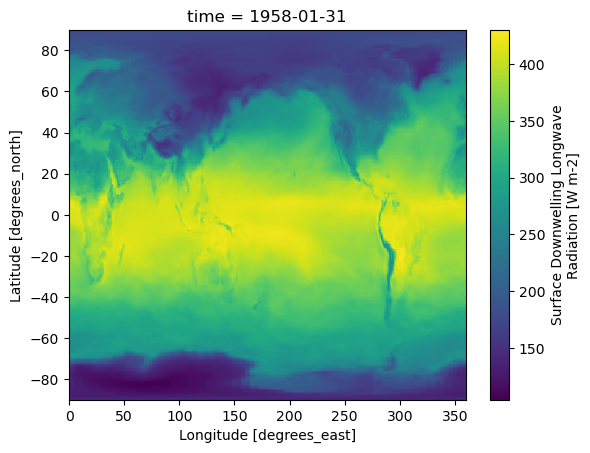

In [10]:
rlds_1958_mon.isel(time=0).plot()

In [11]:
list(lw_ceres.data_vars)
ceres_lw = lw_ceres["sfc_lw_down_all_mon"]
ceres_lw

<xarray.DataArray 'sfc_lw_down_all_mon' (time: 304, lat: 180, lon: 360)> Size: 79MB
[19699200 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2025-06-15
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    long_name:      Surface Longwave Flux Down, All-Sky conditions, Monthly M...
    standard_name:  Surface Longwave Flux Down - All-Sky
    CF_name:        surface_downwelling_longwave_flux_in_air
    comment:        none
    units:          W m-2
    valid_min:            40.0000
    valid_max:            500.000

In [12]:
# Open all files together
jra_all = xr.open_mfdataset(
    os.path.join(jra_dir, "*.nc"),
    combine="by_coords",
    chunks={"time": 2920},   # one-year chunks in time
)

rlds_all = jra_all["rlds"]

# 3-hourly convert to monthly mean
rlds_mon = rlds_all.resample(time="1MS").mean("time")

# Restrict to the period overlapping CERES (JRA55 ~2019)
rlds_mon = rlds_mon.sel(time=slice("2000-03-01", "2019-12-31"))

rlds_mon

/jobfs/156245838.gadi-pbs/ipykernel_2815212/2040026594.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  jra_all = xr.open_mfdataset(


<xarray.DataArray 'rlds' (time: 227, lat: 320, lon: 640)> Size: 186MB
dask.array<getitem, shape=(227, 320, 640), dtype=float32, chunksize=(12, 320, 640), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-03-01 2000-04-01 ... 2019-01-01
  * lat      (lat) float64 3kB -89.57 -89.01 -88.45 -87.89 ... 88.45 89.01 89.57
  * lon      (lon) float64 5kB 0.0 0.5625 1.125 1.688 ... 358.3 358.9 359.4
Attributes:
    standard_name:  surface_downwelling_longwave_flux_in_air
    long_name:      Surface Downwelling Longwave Radiation
    comment:        The surface called 'surface' means the lower boundary of ...
    units:          W m-2
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [13]:
print("CERES time (first 5):")
print(ceres_lw.time.isel(time=slice(0, 5)))

print("\nCERES time (last 5):")
print(ceres_lw.time.isel(time=slice(-5, None)))

print("\nJRA55 rlds_mon time (first 5):")
print(rlds_mon.time.isel(time=slice(0, 5)))

print("\nJRA55 rlds_mon time (last 5):")
print(rlds_mon.time.isel(time=slice(-5, None)))

CERES time (first 5):
<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['2000-03-15T00:00:00.000000000', '2000-04-15T00:00:00.000000000',
       '2000-05-15T00:00:00.000000000', '2000-06-15T00:00:00.000000000',
       '2000-07-15T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2000-03-15 2000-04-15 ... 2000-07-15
Attributes:
    long_name:  time
    delta_t:    0000-00-01 00:00:00

CERES time (last 5):
<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['2025-02-15T00:00:00.000000000', '2025-03-15T00:00:00.000000000',
       '2025-04-15T00:00:00.000000000', '2025-05-15T00:00:00.000000000',
       '2025-06-15T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2025-02-15 2025-03-15 ... 2025-06-15
Attributes:
    long_name:  time
    delta_t:    0000-00-01 00:00:00

JRA55 rlds_mon time (first 5):
<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['2000-03-01T00:00:00.000000000', '2000-04

In [14]:
# Shift CERES timestamps from 15th to 1st to align
ceres_lw_aligned = ceres_lw.copy()

new_time = xr.cftime_range(
    start=f"{int(ceres_lw.time.dt.year[0].values)}-{int(ceres_lw.time.dt.month[0].values):02d}-01",
    periods=ceres_lw.time.size,
    freq="MS",
)

ceres_lw_aligned = ceres_lw_aligned.assign_coords(time=new_time)

print("CERES aligned time (first 5):")
ceres_lw_aligned.time.isel(time=slice(0, 5))

CERES aligned time (first 5):


/jobfs/156245838.gadi-pbs/ipykernel_2815212/1105317140.py:4: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  new_time = xr.cftime_range(


<xarray.DataArray 'time' (time: 5)> Size: 40B
array([cftime.DatetimeGregorian(2000, 3, 1, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2000, 4, 1, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2000, 5, 1, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2000, 6, 1, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2000, 7, 1, 0, 0, 0, 0, has_year_zero=False)],
      dtype=object)
Coordinates:
  * time     (time) object 40B 2000-03-01 00:00:00 ... 2000-07-01 00:00:00

In [15]:
# Replace CERES time with a datetime64 month-start index
new_time_dt = xr.date_range(
    start="2000-03-01",
    periods=ceres_lw.time.size,
    freq="MS",
)

ceres_lw_aligned = ceres_lw.assign_coords(time=new_time_dt)

print("CERES aligned (datetime64) time (first 5):")
ceres_lw_aligned.time.isel(time=slice(0, 5))

CERES aligned (datetime64) time (first 5):


<xarray.DataArray 'time' (time: 5)> Size: 40B
array(['2000-03-01T00:00:00.000000000', '2000-04-01T00:00:00.000000000',
       '2000-05-01T00:00:00.000000000', '2000-06-01T00:00:00.000000000',
       '2000-07-01T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 40B 2000-03-01 2000-04-01 ... 2000-07-01

In [16]:
# slice
start = "2000-03-01"
end   = "2018-12-01"

ceres_common = ceres_lw_aligned.sel(time=slice(start, end))
jra_common   = rlds_mon.sel(time=slice(start, end))

print("CERES common time length:", ceres_common.time.size)
print("JRA55 common time length:", jra_common.time.size)

print("\nCERES common first/last:")
print(ceres_common.time[0].values, "→", ceres_common.time[-1].values)

print("\nJRA55 common first/last:")
print(jra_common.time[0].values, "→", jra_common.time[-1].values)

CERES common time length: 226
JRA55 common time length: 226

CERES common first/last:
2000-03-01T00:00:00.000000000 → 2018-12-01T00:00:00.000000000

JRA55 common first/last:
2000-03-01T00:00:00.000000000 → 2018-12-01T00:00:00.000000000


In [17]:
import xesmf as xe
print("xESMF version:", xe.__version__)

xESMF version: 0.8.7


In [18]:
regridder = xe.Regridder(
    jra_common,
    ceres_common,
    method="bilinear",
    periodic=True,
    reuse_weights=False,
)

jra_on_ceres = regridder(jra_common)
jra_on_ceres

<xarray.DataArray (time: 226, lat: 180, lon: 360)> Size: 59MB
dask.array<astype, shape=(226, 180, 360), dtype=float32, chunksize=(12, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-03-01 2000-04-01 ... 2018-12-01
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    regrid_method:  bilinear

In [19]:
# --- SOTS AoE
sots_lat = -47.0
sots_lon = 142.0

# Extract nearest grid point from CERES and JRA55-on-CERES
ceres_sots = ceres_common.sel(lat=sots_lat, lon=sots_lon, method="nearest")
jra_sots   = jra_on_ceres.sel(lat=sots_lat, lon=sots_lon, method="nearest")

print("CERES SOTS point:")
print("  lat, lon =", float(ceres_sots.lat.values), float(ceres_sots.lon.values))
print("  shape   =", ceres_sots.shape)

print("\nJRA55 SOTS point:")
print("  lat, lon =", float(jra_sots.lat.values), float(jra_sots.lon.values))
print("  shape   =", jra_sots.shape)

CERES SOTS point:
  lat, lon = -46.5 142.5
  shape   = (226,)

JRA55 SOTS point:
  lat, lon = -46.5 142.5
  shape   = (226,)


In [20]:

lat_min, lat_max = -47.5, -46.0
lon_min, lon_max = 141.2, 142.7


ceres_box = ceres_common.sel(lat=slice(lat_min, lat_max),
                             lon=slice(lon_min, lon_max))

jra_box = jra_on_ceres.sel(lat=slice(lat_min, lat_max),
                           lon=slice(lon_min, lon_max))


ceres_series = ceres_box.mean(dim=("lat", "lon"))
jra_series   = jra_box.mean(dim=("lat", "lon"))

print("CERES box mean series:", ceres_series.shape)
print("JRA55 box mean series:", jra_series.shape)

CERES box mean series: (226,)
JRA55 box mean series: (226,)


In [21]:
ceres_series = ceres_series.compute()
jra_series   = jra_series.compute()

print("Done computing.")
print("CERES:", ceres_series.shape, ceres_series.dtype)
print("JRA55:", jra_series.shape, jra_series.dtype)

Done computing.
CERES: (226,) float32
JRA55: (226,) float32


### JRE55 and CERES Comparison

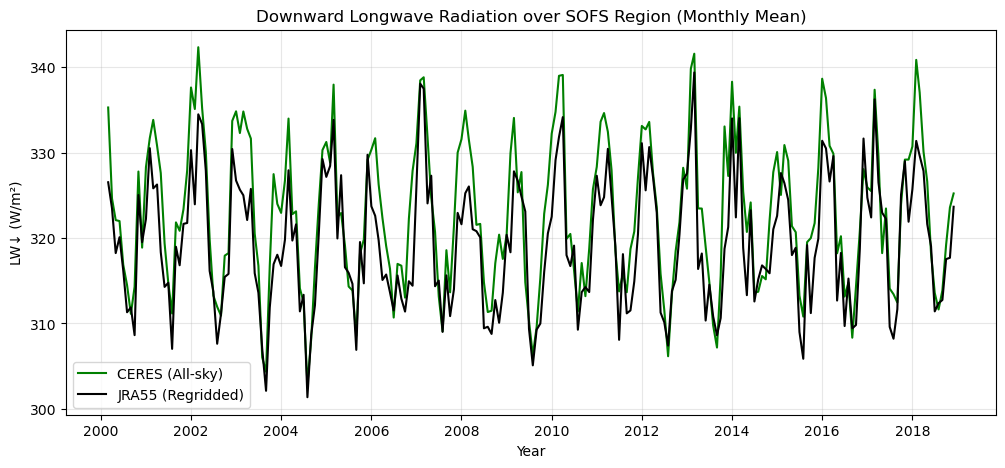

In [22]:
plt.figure(figsize=(12,5))

plt.plot(ceres_series.time, ceres_series, label="CERES (All-sky)", color="green")
plt.plot(jra_series.time, jra_series, label="JRA55 (Regridded)", color="black")

plt.title("Downward Longwave Radiation over SOFS Region (Monthly Mean)")
plt.ylabel("LW↓ (W/m²)")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

### Calculated Anomaly/bias of JRE55

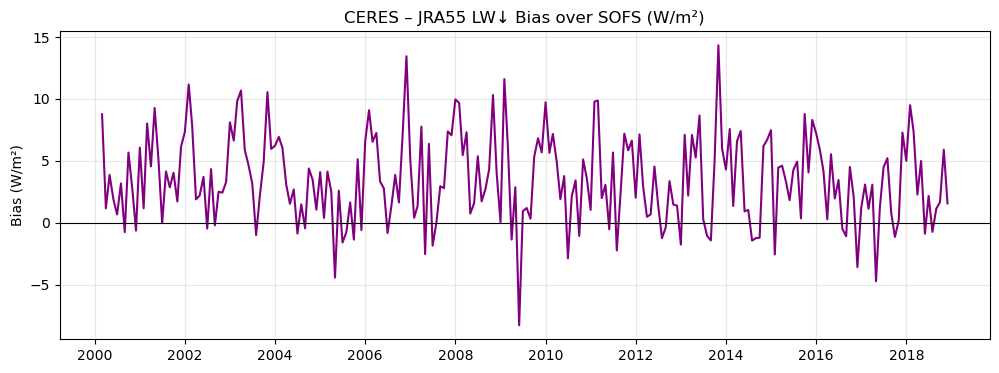

In [23]:
bias = ceres_series - jra_series

plt.figure(figsize=(12,4))
plt.plot(ceres_series.time, bias, color="purple")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("CERES – JRA55 LW↓ Bias over SOFS (W/m²)")
plt.ylabel("Bias (W/m²)")
plt.grid(alpha=0.3)
plt.show()

In [24]:
clim_ceres = ceres_series.groupby("time.month").mean()
clim_jra   = jra_series.groupby("time.month").mean()

### Stats
- Mean bias (CERES-JRA) = +3.5 W/m2
- RMSE = 5 W/m2
- correlation = 0.91

In [25]:

mean_bias = float(bias.mean())
rmse = float(np.sqrt(((bias)**2).mean()))
corr = float(np.corrcoef(ceres_series, jra_series)[0,1])

mean_bias, rmse, corr

(3.4834651947021484, 4.98183192129082, 0.9117420723629858)

### Monthly Climatology for JRE55 and CERES Comparison

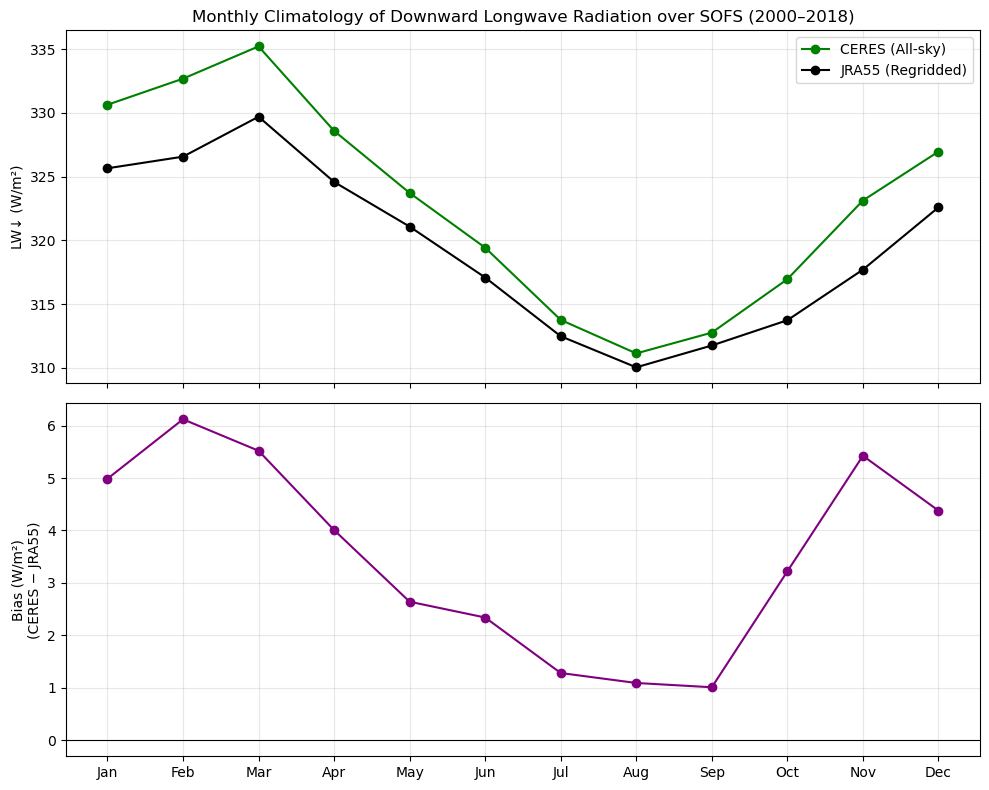

In [26]:
months = np.arange(1, 13)
month_labels = [calendar.month_abbr[m] for m in months]

clim_ceres = ceres_series.groupby("time.month").mean()
clim_jra   = jra_series.groupby("time.month").mean()
clim_bias  = clim_ceres - clim_jra

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


axes[0].plot(months, clim_ceres, marker="o", color="green", label="CERES (All-sky)")
axes[0].plot(months, clim_jra, marker="o", color="black", label="JRA55 (Regridded)")
axes[0].set_ylabel("LW↓ (W/m²)")
axes[0].set_title("Monthly Climatology of Downward Longwave Radiation over SOFS (2000–2018)")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(months, clim_bias, marker="o", color="purple")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Bias (W/m²)\n(CERES − JRA55)")
axes[1].set_xticks(months)
axes[1].set_xticklabels(month_labels)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Global Zonal Average

In [27]:
ceres_zonal = ceres_common.mean(dim="lon")
jra_zonal   = jra_on_ceres.mean(dim="lon")

ceres_zonal, jra_zonal

(<xarray.DataArray 'sfc_lw_down_all_mon' (time: 226, lat: 180)> Size: 163kB
 array([[111.54027 , 111.90018 , 118.3834  , ..., 204.43607 , 202.5071  ,
         201.63287 ],
        [ 95.79157 ,  93.2685  , 103.5156  , ..., 183.43091 , 180.09744 ,
         179.74603 ],
        [102.181404, 102.171776, 109.8107  , ..., 232.95935 , 229.79543 ,
         230.78145 ],
        ...,
        [126.472305, 127.07545 , 125.9359  , ..., 252.94308 , 252.81133 ,
         252.11652 ],
        [134.23795 , 132.17421 , 127.56296 , ..., 220.96666 , 223.32817 ,
         223.69551 ],
        [160.12025 , 155.41832 , 151.58601 , ..., 196.25838 , 200.00745 ,
         202.94264 ]], dtype=float32)
 Coordinates:
   * time     (time) datetime64[ns] 2kB 2000-03-01 2000-04-01 ... 2018-12-01
   * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5,
 <xarray.DataArray (time: 226, lat: 180)> Size: 163kB
 dask.array<mean_agg-aggregate, shape=(226, 180), dtype=float32, chunksize=(12, 180), chunkt

In [1]:
# Time-mean zonal (latitude) profiles
ceres_zm = ceres_zonal.mean(dim="time")
jra_zm   = jra_zonal.mean(dim="time")

bias_zm = ceres_zm - jra_zm

ceres_zm, jra_zm, bias_zm

NameError: name 'ceres_zonal' is not defined

## Global Zonal Mean and bias

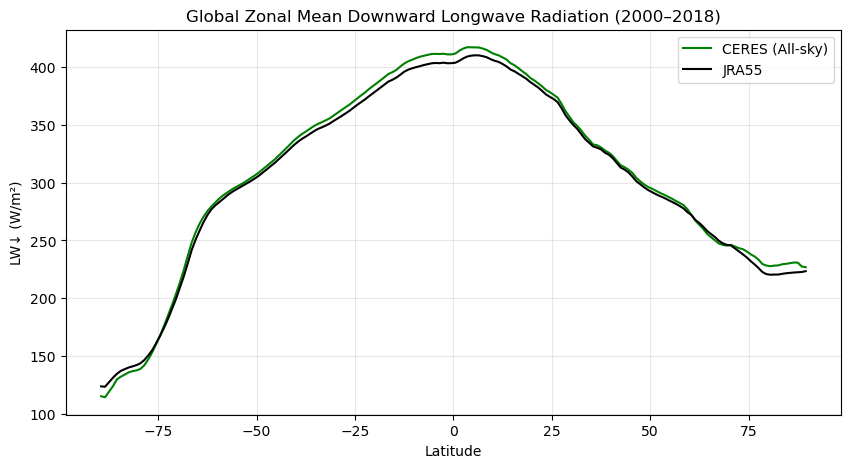

In [29]:
lat = ceres_zm.lat

plt.figure(figsize=(10,5))

plt.plot(lat, ceres_zm, label="CERES (All-sky)", color="green")
plt.plot(lat, jra_zm,   label="JRA55", color="black")

plt.title("Global Zonal Mean Downward Longwave Radiation (2000–2018)")
plt.xlabel("Latitude")
plt.ylabel("LW↓ (W/m²)")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

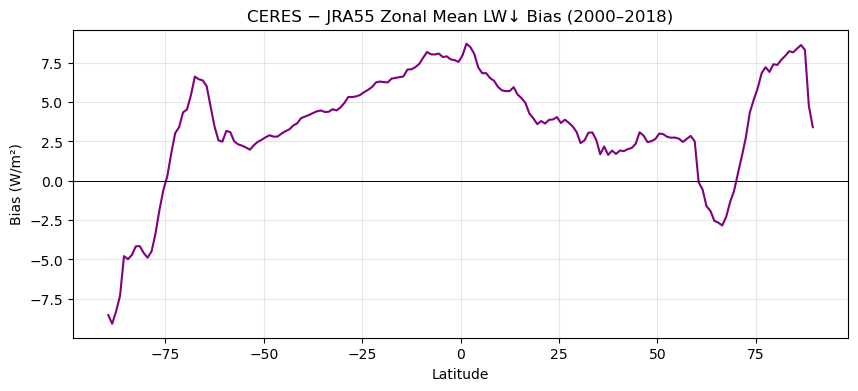

In [30]:
plt.figure(figsize=(10,4))
plt.plot(lat, bias_zm, color="purple")

plt.title("CERES − JRA55 Zonal Mean LW↓ Bias (2000–2018)")
plt.xlabel("Latitude")
plt.ylabel("Bias (W/m²)")
plt.axhline(0, color="black", linewidth=0.7)
plt.grid(alpha=0.3)

plt.show()